In [30]:
import pandas as pd
import numpy as np
import sklearn.preprocessing
import matplotlib.pyplot as plt
%matplotlib inline

In [31]:
df=pd.read_excel('Biology_Topics_9th.xlsx')
df.head()

,Year,Subject,Topic_id,Topic,Appeared,Chapter
0,2025,Biology,1,Introduction To Biology,0,Introduction to Biology
1,2025,Biology,2,Branches of Biology,1,Introduction to Biology
2,2025,Biology,3,Biophysics,0,Introduction to Biology
3,2025,Biology,4,Biochemistry,0,Introduction to Biology
4,2025,Biology,5,Biogeography,0,Introduction to Biology


In [32]:
df.isnull().sum()

Year        0
Subject     0
Topic_id    0
Topic       0
Appeared    0
Chapter     0
dtype: int64

In [33]:
df.shape

(1000, 6)

In [34]:
df[['Year', 'Topic', 'Appeared']].head(10)

,Year,Topic,Appeared
0,2025,Introduction To Biology,0
1,2025,Branches of Biology,1
2,2025,Biophysics,0
3,2025,Biochemistry,0
4,2025,Biogeography,0
5,2025,Biostatistics/Biometry,0
6,2025,Bio-economics,0
7,2025,Carrers in Biology,0
8,2025,Muslim Scientist,0
9,2025,Levels of Biological Organization,1


In [35]:
# Gaps
gaps = []
last_seen = {}

for _, row in df.iterrows():
    topic = row['Topic']
    year = int(row['Year'])
    appeared = row['Appeared']
    
    if topic not in last_seen:
        gaps.append(-1)
    else:
        gaps.append(year - last_seen[topic])
    
    if appeared == 1:
        last_seen[topic] = year

df['Gaps'] = gaps

# Frequency_Last_5
years_in_data = sorted(df['Year'].unique())
frequency = []

for _, row in df.iterrows():
    topic = row['Topic']
    year = row['Year']
    prev_years = [y for y in years_in_data if y < year]
    last_5_years = prev_years[-5:]
    topic_data = df[df['Topic'] == topic]
    count = topic_data[topic_data['Year'].isin(last_5_years)]['Appeared'].sum()
    frequency.append(int(count))

df['Frequency_Last_5'] = frequency

# Appeared_last_year
df['Appeared_last_year'] = df.groupby('Topic')['Appeared'].shift(1).fillna(0)

# rolling_3
df['rolling_3'] = (df.groupby('Topic')['Appeared']
                   .transform(lambda x: x.shift(1).rolling(3).sum())
                   .fillna(0))

# chapter_weight — Chemistry ka ToS se
chapter_weight = {
    'Introduction to Biology': 0.06,
    'Solving a Biological Problem': 0.06,
    'Biodiversity': 0.06,
    'Cell and Tissue': 0.16,
    'Cell Cycle': 0.14,
    'Enzymes': 0.12,
    'Bioenergetics': 0.14,
    'Nutritions': 0.12,
    'Transport': 0.14
}
    
df['chapter_weight'] = df['Chapter'].map(chapter_weight)

In [36]:
df.head()

,Year,Subject,Topic_id,Topic,Appeared,Chapter,Gaps,Frequency_Last_5,Appeared_last_year,rolling_3,chapter_weight
0,2025,Biology,1,Introduction To Biology,0,Introduction to Biology,-1,0,0.0,0.0,0.06
1,2025,Biology,2,Branches of Biology,1,Introduction to Biology,-1,3,0.0,0.0,0.06
2,2025,Biology,3,Biophysics,0,Introduction to Biology,-1,1,0.0,0.0,0.06
3,2025,Biology,4,Biochemistry,0,Introduction to Biology,-1,1,0.0,0.0,0.06
4,2025,Biology,5,Biogeography,0,Introduction to Biology,-1,0,0.0,0.0,0.06


In [37]:
print(df['chapter_weight'].isnull().sum())

0


In [38]:
df_model=df.copy()

## Train Test Split
Here we'll experiment to check how well our model understands pattern that's why we train data on ```2024,2023,2022,2019,2018,2017,2016``` and test on the paper of ```2025```

In [39]:
train = df_model[df_model['Year'] < 2025]
test  = df_model[df_model['Year'] == 2025]

features = ['Gaps', 'Frequency_Last_5','Appeared_last_year','rolling_3','chapter_weight']
targets = 'Appeared'

X_train = train[features]
y_train = train[targets]

X_test = test[features]
y_test = test[targets]

## Baseline Model
  ### ***. LogisticRegression***

In [40]:
from sklearn.linear_model import LogisticRegression
lr_model=LogisticRegression(class_weight='balanced',random_state=42)
# lr_model = LogisticRegression(class_weight='balanced', C=0.1, random_state=42)
lr_model.fit(X_train,y_train)
lr_predict=lr_model.predict(X_test)

### Accuracy , Precision , Recall

In [41]:
from sklearn.metrics import accuracy_score,precision_score,recall_score
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
accuracy_lr=accuracy_score(y_test,lr_predict)
precision_lr=precision_score(y_test,lr_predict)
recall_lr=recall_score(y_test,lr_predict)
print(f"Accuracy:  {accuracy_lr * 100:.2f}%")
print(f'Precision:{precision_lr*100:.2f}%')
print(f'Recall:{recall_lr*100:.2f}%')

Accuracy:  74.40%
Precision:46.34%
Recall:65.52%


### Accuarcy , Classification Report On Different Threshold

In [42]:
from sklearn.metrics import classification_report

y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

for threshold in [0.5, 0.4, 0.3, 0.25]:
    y_pred_thresh = (y_prob_lr >= threshold).astype(int)
    print(f'Accuracy:{accuracy_score(y_test,y_pred_thresh)*100:.2f}%')
    print(f"\nThreshold={threshold}")
    print(classification_report(y_test, y_pred_thresh))

Accuracy:74.40%

Threshold=0.5
              precision    recall  f1-score   support

           0       0.88      0.77      0.82        96
           1       0.46      0.66      0.54        29

    accuracy                           0.74       125
   macro avg       0.67      0.71      0.68       125
weighted avg       0.78      0.74      0.76       125

Accuracy:74.40%

Threshold=0.4
              precision    recall  f1-score   support

           0       0.88      0.77      0.82        96
           1       0.46      0.66      0.54        29

    accuracy                           0.74       125
   macro avg       0.67      0.71      0.68       125
weighted avg       0.78      0.74      0.76       125

Accuracy:58.40%

Threshold=0.3
              precision    recall  f1-score   support

           0       0.91      0.51      0.65        96
           1       0.34      0.83      0.48        29

    accuracy                           0.58       125
   macro avg       0.62      0.67  

c:\Users\aliah\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aliah\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aliah\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

## Essemble Model
### ***. Random Forest***

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight='balanced',n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred=rf_model.predict(X_test)

In [44]:
from sklearn.metrics import accuracy_score,precision_score,recall_score
rf_accuracy=accuracy_score(y_test,rf_pred)
rf_precision=precision_score(y_test,rf_pred)
rf_recall=recall_score(y_test,rf_pred)
print(f'Accuarcy:{rf_accuracy*100:.2f}%')
print(f'Precision:{rf_precision*100:.2f}%')
print(f'Recall:{rf_recall*100:.2f}%')

Accuarcy:67.20%
Precision:26.92%
Recall:24.14%


#### Accuracy and Classification Report on different Threshold

In [45]:
from sklearn.metrics import classification_report, accuracy_score
prob = rf_model.predict_proba(X_test)[:,1]
for t in[0.5,0.4,0.3,0.25]:
    pred=(prob>t).astype(int)
    print("Accuracy:", accuracy_score(y_test,pred))
    print(f'Threshold={t}',classification_report(y_test,pred))

Accuracy: 0.672
Threshold=0.5               precision    recall  f1-score   support

           0       0.78      0.80      0.79        96
           1       0.27      0.24      0.25        29

    accuracy                           0.67       125
   macro avg       0.52      0.52      0.52       125
weighted avg       0.66      0.67      0.67       125

Accuracy: 0.64
Threshold=0.4               precision    recall  f1-score   support

           0       0.79      0.73      0.76        96
           1       0.28      0.34      0.31        29

    accuracy                           0.64       125
   macro avg       0.53      0.54      0.53       125
weighted avg       0.67      0.64      0.65       125

Accuracy: 0.576
Threshold=0.3               precision    recall  f1-score   support

           0       0.84      0.55      0.67        96
           1       0.31      0.66      0.42        29

    accuracy                           0.58       125
   macro avg       0.57      0.60      

## Boosting Model
### ***. XGBoost***

In [46]:
from xgboost import XGBClassifier
xg_model = XGBClassifier(scale_pos_weight=3, random_state=42)
xg_model.fit(X_train, y_train)
xg_pred=xg_model.predict(X_test)

In [47]:
from sklearn.metrics import accuracy_score,precision_score,recall_score
xg_accuracy=accuracy_score(y_test,xg_pred)
xg_precision=precision_score(y_test,xg_pred)
xg_recall=recall_score(y_test,xg_pred)
print(f'Accuracy:{xg_accuracy*100:.2f}%')
print(f'Precison:{xg_precision*100:.2f}%')
print(f'Recall:{xg_recall*100:.2f}%')

Accuracy:68.00%
Precison:29.63%
Recall:27.59%


### Accuracy and Classification Report On Different Threshold

In [48]:
prob =xg_model.predict_proba(X_test)[:,1]

for t in [0.5, 0.4, 0.3, 0.25]:
    pred = (prob > t).astype(int)
    print("Accuracy:", accuracy_score(y_test, pred))
    print(f'Threshold={t}', classification_report(y_test, pred))

Accuracy: 0.68
Threshold=0.5               precision    recall  f1-score   support

           0       0.79      0.80      0.79        96
           1       0.30      0.28      0.29        29

    accuracy                           0.68       125
   macro avg       0.54      0.54      0.54       125
weighted avg       0.67      0.68      0.68       125

Accuracy: 0.648
Threshold=0.4               precision    recall  f1-score   support

           0       0.85      0.66      0.74        96
           1       0.35      0.62      0.45        29

    accuracy                           0.65       125
   macro avg       0.60      0.64      0.60       125
weighted avg       0.74      0.65      0.67       125

Accuracy: 0.576
Threshold=0.3               precision    recall  f1-score   support

           0       0.84      0.55      0.67        96
           1       0.31      0.66      0.42        29

    accuracy                           0.58       125
   macro avg       0.57      0.60      

In [49]:
comparison=pd.DataFrame({
    'Accuracy':[accuracy_lr*100,rf_accuracy*100,xg_accuracy*100],
    'Precision':[precision_lr*100,rf_precision*100,xg_precision*100],
    'Recall':[recall_lr*100,rf_recall*100,xg_recall*100] 
},index=['LogisticRegression','Random Forest','XGBoost'])
comparison=comparison.round(2)

In [50]:
print("\t=== Comparison of Models ===")
print(comparison)

	=== Comparison of Models ===
                    Accuracy  Precision  Recall
LogisticRegression      74.4      46.34   65.52
Random Forest           67.2      26.92   24.14
XGBoost                 68.0      29.63   27.59


### Prediction For 2026

In [59]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Step 1 - Full data pe train karo
features = ['Gaps', 'Frequency_Last_5', 'Appeared_last_year', 'rolling_3', 'chapter_weight']
targets = 'Appeared'

X_full = df_model[features].copy()
y_full = df_model[targets]

pipe_full = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
pipe_full.fit(X_full, y_full)

# Step 2 - 2026 ka base
df_2026 = df[df['Year'] == 2025][['Topic_id', 'Topic', 'Chapter', 'Appeared', 'Gaps',
              'Frequency_Last_5', 'Appeared_last_year',
              'rolling_3', 'chapter_weight']].copy()
df_2026['Year'] = 2026

# Step 3 - Features update
df_2026['Appeared_last_year'] = df_2026['Appeared']
df_2026['Gaps'] = df_2026.apply(
    lambda row: 1 if row['Appeared'] == 1 else row['Gaps'] + 1, axis=1)
df_2026['Frequency_Last_5'] = df_2026.apply(
    lambda row: min(5, row['Frequency_Last_5'] + row['Appeared']), axis=1)
df_2026['rolling_3'] = df_2026.apply(
    lambda row: min(3, row['rolling_3'] + row['Appeared']), axis=1)

# Step 4 - Predict
X_2026 = df_2026[features].copy()
prob_2026 = pipe_full.predict_proba(X_2026)[:, 1]
df_2026['Probability'] = prob_2026

# Step 5 - Filter + Category
result_2026 = df_2026[['Topic_id', 'Topic', 'Chapter', 'Probability']]\
              .sort_values('Probability', ascending=False)\
              .reset_index(drop=True)

final_predictions = result_2026[result_2026['Probability'] >= 0.5].head(25).copy()

final_predictions['Category'] = final_predictions['Probability'].apply(
    lambda x: 'A - Must Prepare' if x >= 0.7 else 'B - Should Prepare'
)

# Step 6 - Years appeared nikalo
appeared_years_list = []
for _, row in final_predictions.iterrows():
    topic = row['Topic']
    years = df[
        (df['Topic'] == topic) &
        (df['Appeared'] == 1)
    ]['Year'].tolist()
    appeared_years_list.append(', '.join(map(str, sorted(years))))

final_predictions['Years_Appeared'] = appeared_years_list
final_predictions['Total_Appearances'] = final_predictions['Years_Appeared'].apply(
    lambda x: len(x.split(', ')) if x else 0
)

# Step 7 - Save
final_predictions.to_excel('Biology_9th_Predictions_2026.xlsx', index=False)
print(final_predictions)

    Topic_id                                   Topic  \
0         23                     Five Kingdom System   
1        121                             Human Heart   
2        123                         Aertial System    
3         64                 Significance Of mitosis   
4         17     Data Organization and Data Analysis   
5          2                     Branches of Biology   
6        109                 Malnutrition and Causes   
7         66                               Meiosis I   
8         69                  Apoptosis and Necrosis   
9         57                           Animal Tissue   
10       110                  Human Digestive System   
11        75                        Induce Fit Model   
12       103                                Vitamins   
13        81      ATP as the Energy Currency Of cell   
14       114  Factor Effecting Rate of Transpiration   
15        62                  Mitosis and Its Stages   
16        91                     Aerobic Respira

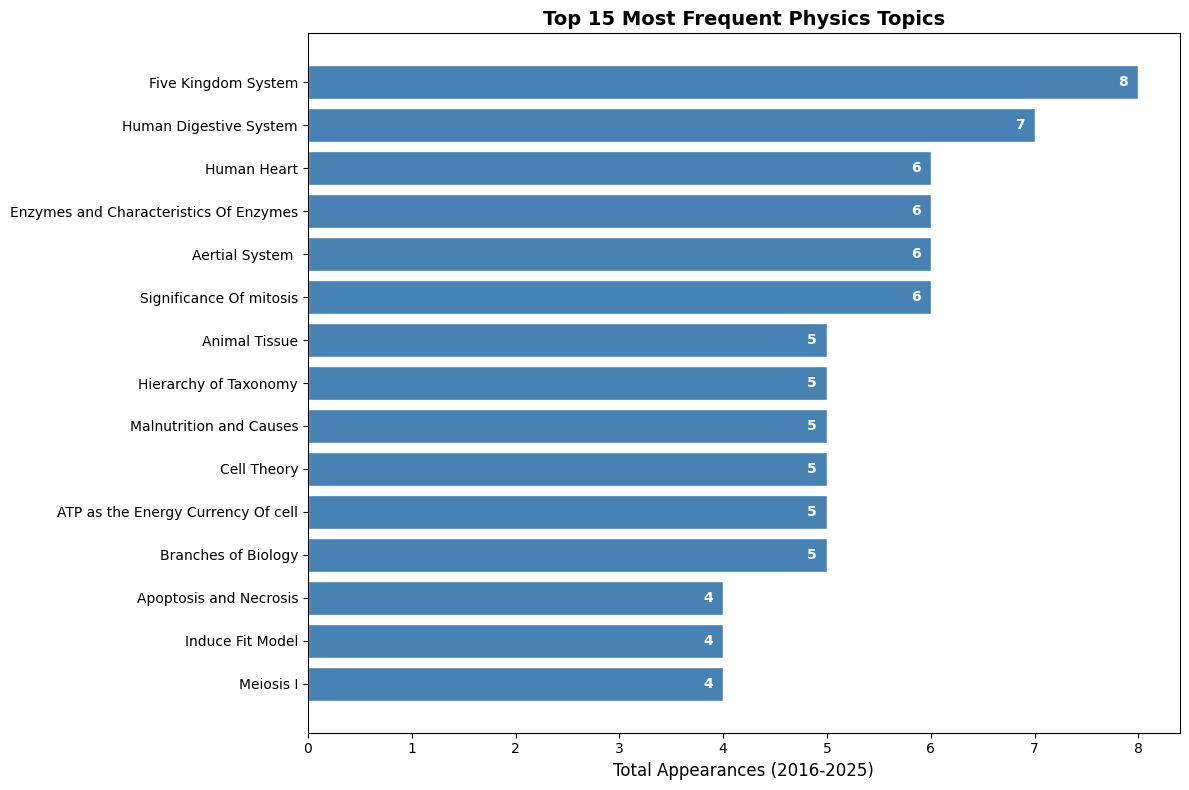

In [54]:
import matplotlib.pyplot as plt

topic_freq = df.groupby('Topic')['Appeared'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(topic_freq.index, topic_freq.values, color='steelblue', edgecolor='white')
plt.xlabel('Total Appearances (2016-2025)', fontsize=12)
plt.title('Top 15 Most Frequent Physics Topics', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Values bar ke andar dikhao
for bar, val in zip(bars, topic_freq.values):
    plt.text(val - 0.1, bar.get_y() + bar.get_height()/2, 
             str(int(val)), va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('graph1_frequency.png', dpi=150)
plt.show()

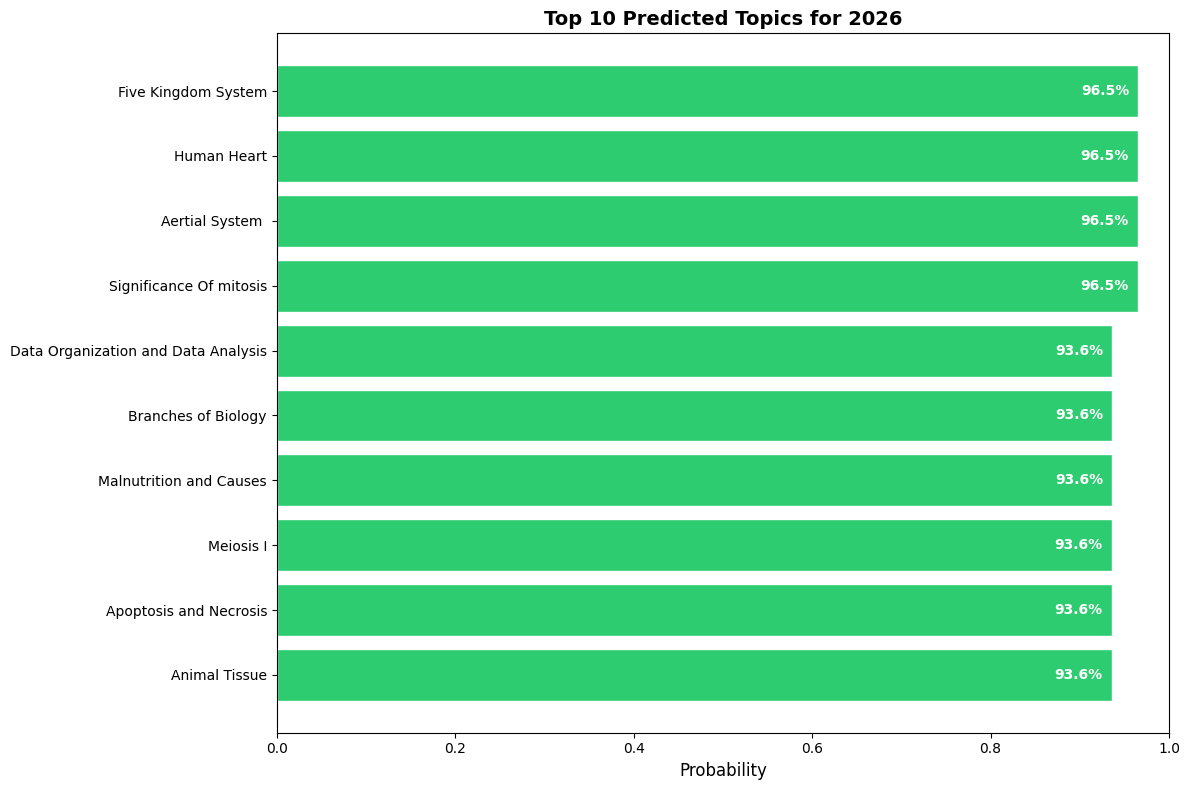

In [55]:
top10 = result_2026.head(10)

plt.figure(figsize=(12, 8))
colors = ['#2ecc71' if p >= 0.85 else '#f39c12' if p >= 0.80 else '#e74c3c' 
          for p in top10['Probability']]
bars = plt.barh(top10['Topic'], top10['Probability'], color=colors, edgecolor='white')
plt.xlabel('Probability', fontsize=12)
plt.title('Top 10 Predicted Topics for 2026', fontsize=14, fontweight='bold')
plt.xlim(0, 1)
plt.gca().invert_yaxis()

for bar, val in zip(bars, top10['Probability']):
    plt.text(val - 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.1%}', va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('graph2_predictions.png', dpi=150)
plt.show()

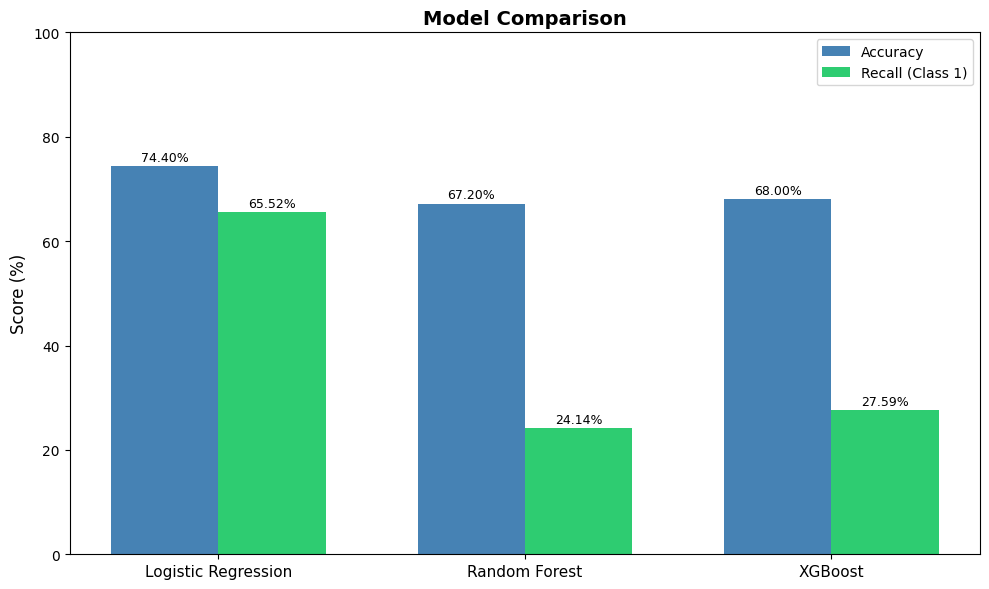

In [56]:
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracy = [accuracy_lr*100, rf_accuracy*100, xg_accuracy*100]
recall = [recall_lr*100, rf_recall*100, xg_recall*100]

x = range(len(models))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - width/2 for i in x], accuracy, width, label='Accuracy', color='steelblue')
plt.bar([i + width/2 for i in x], recall, width, label='Recall (Class 1)', color='#2ecc71')

plt.ylabel('Score (%)', fontsize=12)
plt.title('Model Comparison', fontsize=14, fontweight='bold')
plt.xticks(x, models, fontsize=11)
plt.legend()
plt.ylim(0, 100)

for i, (acc, rec) in enumerate(zip(accuracy, recall)):
    plt.text(i - width/2, acc + 1, f'{acc:.2f}%', ha='center', fontsize=9)
    plt.text(i + width/2, rec + 1, f'{rec:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('graph3_model_comparison.png', dpi=150)
plt.show()

In [57]:
result_2026.head(20).to_excel('Predicted_Biology_Topics_Class_9th_2026.xlsx', index=False)
print("File saved!")

File saved!


In [58]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
print(f"Dummy Accuracy: {accuracy_score(y_test, dummy.predict(X_test)):.4f}")

Dummy Accuracy: 0.7680
